# **AUTOENCODER**

Khởi tạo mô hình

In [ ]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

Khởi tạo dữ liệu

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


Xây dựng mô hình Autoencoder

In [ ]:
from keras.src.regularizers.regularizers import L1
encoding_dim = 32
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(encoding_dim ,activation="relu")(input_img)
decoded = layers.Dense(784, activation="sigmoid")(encoded)
autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))


Huấn luyện mô hình

In [ ]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.0102 - loss: 0.2790 - val_accuracy: 0.0140 - val_loss: 0.1884
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0117 - loss: 0.1695 - val_accuracy: 0.0100 - val_loss: 0.1532
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.0108 - loss: 0.1442 - val_accuracy: 0.0110 - val_loss: 0.1332
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0104 - loss: 0.1280 - val_accuracy: 0.0108 - val_loss: 0.1206
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0106 - loss: 0.1172 - val_accuracy: 0.0095 - val_loss: 0.1116
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0100 - loss: 0.1097 - val_accuracy: 0.0115 - val_loss: 0.1054
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0109 - loss: 0.1045 - val_accuracy: 0.0124 - val_loss: 0.1013
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0110 - loss: 0.1010 - val_accu

Dự báo loại ảnh sử dụng Autoencoder

In [ ]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Hiển thị ảnh từ mô hình

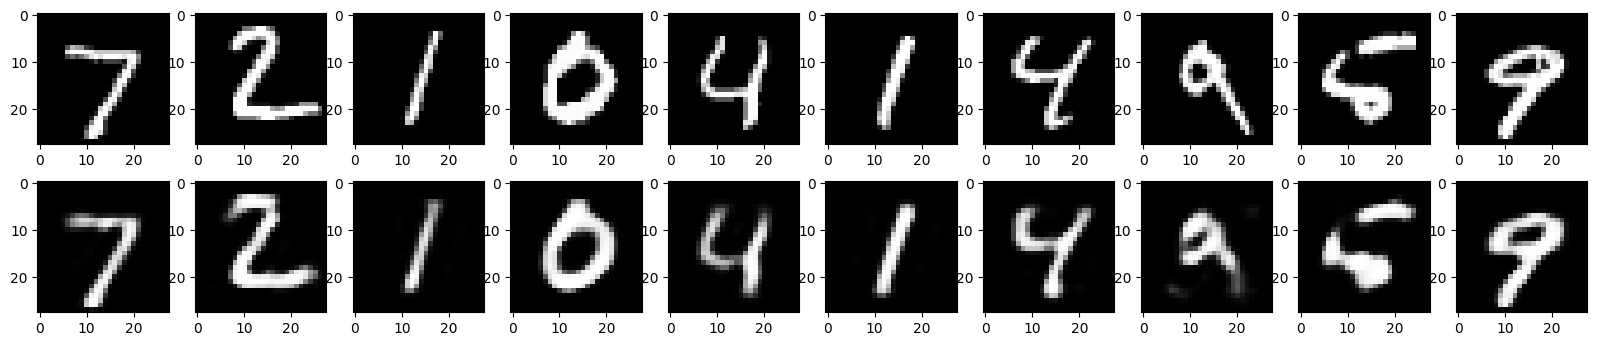

In [ ]:
import matplotlib.pyplot as plt
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()

plt.show()

Mô hình encoder có thêm L1

In [ ]:
from keras.src.regularizers.regularizers import L1
encoding_dim = 32
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(encoding_dim, activity_regularizer=L1 ,activation="relu")(input_img)
decoded = layers.Dense(784, activation="sigmoid")(encoded)
autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.0145 - loss: 0.8999 - val_accuracy: 0.0161 - val_loss: 0.6162
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0151 - loss: 0.5838 - val_accuracy: 0.0161 - val_loss: 0.5538
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.5277 - val_accuracy: 0.0161 - val_loss: 0.5039
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0150 - loss: 0.4829 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0150 - loss: 0.4467 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0149 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.0150 - loss: 0.3739 - val_accu

Thêm layer

In [ ]:
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(128, activation="relu")(input_img)
encoded = layers.Dense(64, activation="relu")(encoded)
encoded = layers.Dense(32, activation="relu")(encoded)

decoded = layers.Dense(784, activation="sigmoid")(encoded)

autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(32,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

Bài tập AUTOENCODER